<a href="https://colab.research.google.com/github/TamannaSaini999/AttoGPT/blob/main/AttoGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AttoGPT

## Language Modeling
- Ruimin Zhang and Tamanna Saini

We tried to create a really small version of GPT.
Basically we're going to create the smallest working example of GPT.

- This is based on Andrej Karpathy's [NanoGPT](https://www.youtube.com/watch?v=kCc8FmEb1nY)
- [GPT-3 Paper](https://arxiv.org/abs/2005.14165)
-Credit to : Steven Walton

We'll first start by defining the parts of GPT


In [ ]:
import math
import torch
from torch import nn
import torch.nn.functional as F

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"

# Our dataset
We're not going to train on a huge amount of data like GPT did. Instead we'll use a relatively small dataset, which is the entire works of Shakespeare, called Tiny Shakespeare. Our goal will be to train a NLP model that can babble in a Shakespearian way. Probably won't be good, but we should be able to do a lot better by just changing a few parameters.

In [ ]:
# Get our dataset: Tiny Shakespeare
!wget -O ./tinyshakespeare.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2023-03-18 04:07:07--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘./tinyshakespeare.txt’

./tinyshakespeare.t 100%[===================>]   1.06M  --.-KB/s    in 0.008s  

2023-03-18 04:07:08 (135 MB/s) - ‘./tinyshakespeare.txt’ saved [1115394/1115394]



In [ ]:
dataset = "tinyshakespeare.txt"
with open(dataset, 'r', encoding='utf-8') as f:
    text = f.read()
chars = sorted(list(set(text)))

vocab_size = len(chars)
batch_size = 4
block_size = 8

# Config
For easy configuration changes we have a dictionary here that will keep track The important variables here are `nembed`, `vocab_size`, `block_size`, and `nlayers`.

We have commented out better parameters but in the cel above we give simple ones to make a very minimal working example

In [ ]:
nembed = 128
#vocab_size = 1024
#block_size = 64
config = {
    "vocab_size": vocab_size,
    "nlayers": 1,
    "dropout": 0.1,
    "block_size": block_size,
    "token_embedding":
    {
        "num_embeddings": vocab_size,
        "embedding_dim": nembed,
    },
    "pos_embedding":
    {
        "num_embeddings": block_size,
        "embedding_dim": nembed,
    },
    "lm_head": {
        "in_features": nembed,
        "out_features": vocab_size,
        "bias": False,
    },
    "block":{
        "norm": {
            "nembed": nembed,
            "bias": False,
        },
        "attn" : {
            "bias": False,
            "nembed": nembed,
            "nheads": 4,
            "dropout": 0.1,
            "block_size": block_size,
        },
        "mlp": {
            "bias": False,
            "nembed": nembed,
            "dropout": 0.1,
            "scale": 4,
            "act": nn.GELU(),
        },
    },

}

In [ ]:
class TransformerBlock(nn.Module):
    '''
    Note that there's been a change from the AIAYN paper: now we
    do "pre-norm" instead of "post-norm". This is more effective.
    '''
    def __init__(self, cdict):
        super().__init__()
        self.ln_1 = LayerNorm(**cdict["norm"])
        self.attn = CausalSelfAttention(**cdict["attn"])
        self.ln_2 = LayerNorm(**cdict["norm"])
        self.mlp = MLP(**cdict["mlp"])

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

We make the simple layernorm block.

In [ ]:
class LayerNorm(nn.Module):
    """
    LayerNorm but with an optional bias.
    """

    def __init__(self, nembed, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(nembed))
        self.bias = nn.Parameter(torch.zeros(nembed)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

We then define the MLP. We'll add some flexibility to Karpathy's code to allow different activation functions.

In [ ]:
class MLP(nn.Module):

    def __init__(self, nembed, bias, dropout=0.0, scale=4, act=nn.GELU()):
        super().__init__()
        self.c_fc    = nn.Linear(nembed, scale * nembed, bias=bias)
        self.c_proj  = nn.Linear(scale * nembed, nembed, bias=bias)
        self.dropout = nn.Dropout(dropout)
        self.act = act

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

Now we'll get to "Causal" Attention , we can actually represent this with a triangular masking.

In [ ]:
a = torch.ones(3,3).tril()
a = a/a.sum(dim=1, keepdim=True)
b = torch.tensor([[1,2,3],[4,5,6],[7,8,9]], dtype=torch.float32)
c = a @ b
print(f"a = {a.shape}\n{a.numpy()}")
print(f"b = {b.shape}\n{b.numpy()}")
print(f"c = a @ b {c.shape}\n{c.numpy()}")

a = torch.Size([3, 3])
[[1.         0.         0.        ]
 [0.5        0.5        0.        ]
 [0.33333334 0.33333334 0.33333334]]
b = torch.Size([3, 3])
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
c = a @ b torch.Size([3, 3])
[[1.  2.  3. ]
 [2.5 3.5 4.5]
 [4.  5.  6. ]]


In [ ]:
tril = torch.tril(torch.ones(3,3))
a = torch.zeros(3,3)
a = a.masked_fill(tril==0, float('-inf')) # -Inf so we just look at components that matter
a = F.softmax(a, dim=-1)

b = torch.tensor([[1,2,3],[4,5,6],[7,8,9]], dtype=torch.float32)

print(a@b)

tensor([[1.0000, 2.0000, 3.0000],
        [2.5000, 3.5000, 4.5000],
        [4.0000, 5.0000, 6.0000]])


We use softmax in the above code cell, but something important is that softmax can tend towards one-hot vectors and to avoid this, we scale with $d_k$, where $d$ is the embedding dimension of head $k$.

In [ ]:
x = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5])
print(F.softmax(x, dim=-1))
print(F.softmax(x*8, dim=-1))
print(F.softmax(x*100, dim=-1))

tensor([0.1621, 0.1792, 0.1980, 0.2188, 0.2419])
tensor([0.0229, 0.0509, 0.1133, 0.2520, 0.5609])
tensor([4.2482e-18, 9.3572e-14, 2.0611e-09, 4.5398e-05, 9.9995e-01])


In [ ]:
class CausalSelfAttention(nn.Module):

    def __init__(self, nembed, nheads, bias=False, dropout=0.1, block_size=64):
        super().__init__()
        assert nembed % nheads == 0
        self.c_attn = nn.Linear(nembed, 3 * nembed, bias=bias)
        # output projection
        self.c_proj = nn.Linear(nembed, nembed, bias=bias)
        # regularization
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.nheads = nheads
        self.nembed = nembed
        self.dropout = dropout
        # causal mask to ensure that attention is only applied to the left in the input sequence
        self.register_buffer("bias", torch.tril(torch.ones(block_size, block_size))
                                    .view(1, 1, block_size, block_size))

    def forward(self, x):
        # batch size, sequence length, embedding dimensionality (n_embd)
        B, T, C = x.size()

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k ,v  = self.c_attn(x).split(self.nembed, dim=2)
        k = k.view(B, T, self.nheads, C // self.nheads).transpose(1, 2)
        q = q.view(B, T, self.nheads, C // self.nheads).transpose(1, 2)
        v = v.view(B, T, self.nheads, C // self.nheads).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

# GPT!!!
Now we're going to create the main GPT program!
We remove some functions from Karpathy's implementation because they are unimportant for us and mostly concerned with loading GPT checkpoints.



In [ ]:
class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config['vocab_size'] is not None
        assert config['block_size'] is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(**config["token_embedding"]),
            wpe = nn.Embedding(**config["pos_embedding"]),
            drop = nn.Dropout(config["dropout"]),
            h = nn.ModuleList([TransformerBlock(config["block"]) for _ in range(config["nlayers"])]),
            ln_f = LayerNorm(**config["block"]["norm"]),
        ))
        self.lm_head = nn.Linear(**config["lm_head"])
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config["nlayers"]))

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config["block_size"], f"Cannot forward sequence of length {t}, block size is only {self.config['block_size']}"
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0) # shape (1, t)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        return x
# Karpathy's version that we removed
#         if targets is not None:
#             # if we are given some desired targets also calculate the loss
#             logits = self.lm_head(x)
#             loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
#         else:
#             # inference-time mini-optimization: only forward the lm_head on the very last position
#             logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
#             loss = None

#         return logits, loss

    def loss(self, idx, targets):
        x = self.forward(idx=idx, targets=targets)
        logits = self.lm_head(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        return logits, loss

    def crop_block_size(self, block_size):
        assert block_size <= self.config["block_size"]
        self.config["block_size"] = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            block.attn.bias = block.attn.bias[:,:,:block_size,:block_size]

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config["block_size"] else idx[:, -self.config["block_size"]:]
            x = self.forward(idx_cond)
            logits = self.lm_head(x[:, [-1], :])

            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [ ]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

In [ ]:
# let's now encode the entire text dataset and store it into a torch.Tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
#
# Split into train and validation sets
split = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:split]
val_data = data[split:]

torch.Size([1115394]) torch.int64


In [ ]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

In [ ]:
lr = 1e-3
model = GPT(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

number of parameters: 0.21M


In [ ]:
def train(model, nsteps, batch_size):
    step_iter = tqdm(range(nsteps),
                     desc=f"Loss: --")

    loss_history = []
    for s in step_iter: # increase number of steps for good results...

        xb, yb = get_batch('train')

        # evaluate the loss
        logits, loss = model.loss(xb.to(device), yb.to(device))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        step_iter.set_description(f"Step [ {s} / {nsteps} :: Loss: {loss.item():.3f}")
    print(f"Final loss: {loss.item()}")
    return loss_history


In [ ]:
def make_plots(loss_history, last_n=None):
    if last_n is not None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
    else:
        fig, (ax1) = plt.subplots(1, 1, figsize=(20,10))

    fig.suptitle("Loss History", fontsize="xx-large")
    ax1.plot(loss_history)
    ax1.set_title("Full History", fontsize="x-large")
    ax1.set_ylabel("Loss")
    ax1.set_xlabel("Step")
    if last_n is not None:
        ax2.plot(range(nsteps-last_n, nsteps), loss_history[-last_n:])
        ax2.set_title(f"Last {last_n} Steps")
        ax2.set_ylabel("Loss")
        ax2.set_xlabel("Step")

Loss: --:   0%|          | 0/1000 [00:00<?, ?it/s]

Final loss: 1.8666633367538452


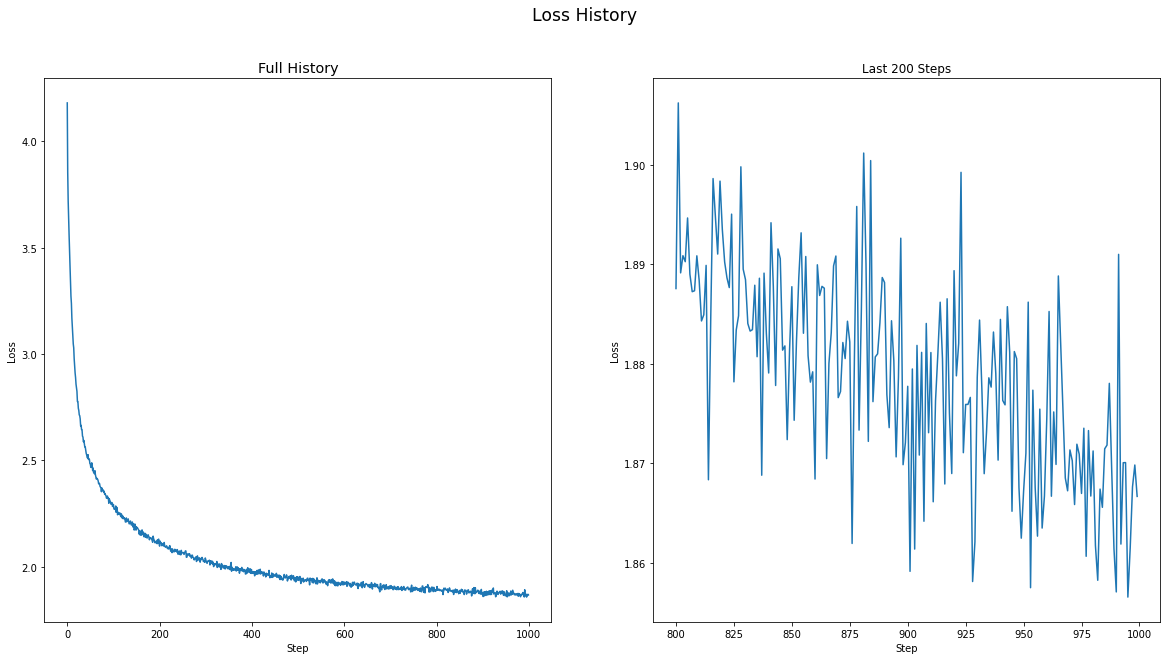

In [ ]:
batch_size = 4096
nsteps = 1000


loss_history = train(model, nsteps, batch_size)
make_plots(loss_history, last_n=200)

Clearly here we see that there isn't convergence BUT we do see that the noise is relatively large compared to the $\Delta $y.
So our model definitely is learning.
The loss is decreasing and doing quite well.




In [ ]:
print(decode(model.generate(idx = torch.zeros((1, 1), dtype=torch.long).to(device), max_new_tokens=500)[0].tolist()))


Messe prut buht speerief'sine him compatingn that in trutch firse:
That a douth perfult the us dom'd, thee it god ookful eyivit me:
'For treach;
Bunce:
He kninio, go you'll the with your we dime, teract in evemended the ead -capeln: then with that a for very neem'd to a O' courence, till gracess:
Nay,
And to That sting tirest brateful me
Have badry, that weard will him.

CAMINQUin confather not you?

QUEENight mean morn, a kitinge of gharled,
My no spesencey
And and losts ere to ghands not 'ust 


So not quite Shakespearean but it is finding the pattern of how there's a character name and then more text after that.
Our model is learning, even if not well, but we do have only 210k parameters.
But we're getting close to actually generating text (we did generate real words!)
Nonsensical, but technically English.

Okay, so let's make the model a bit bigger.
Let's move from AttoGPT. For this we'll 20x our model size.

Let's look at some of the actual text to compare.
We'll print out the first 200 characters from the text

In [ ]:
print(text[:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [ ]:
# nembed = 128
# vocab_size = 1024
#block_size = 64
config['nlayers'] = 20
config['block']['attn']['nheads'] = 8

lr = 1e-3
model = GPT(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

number of parameters: 3.95M


Loss: --:   0%|          | 0/2000 [00:00<?, ?it/s]

Final loss: 1.6229768991470337


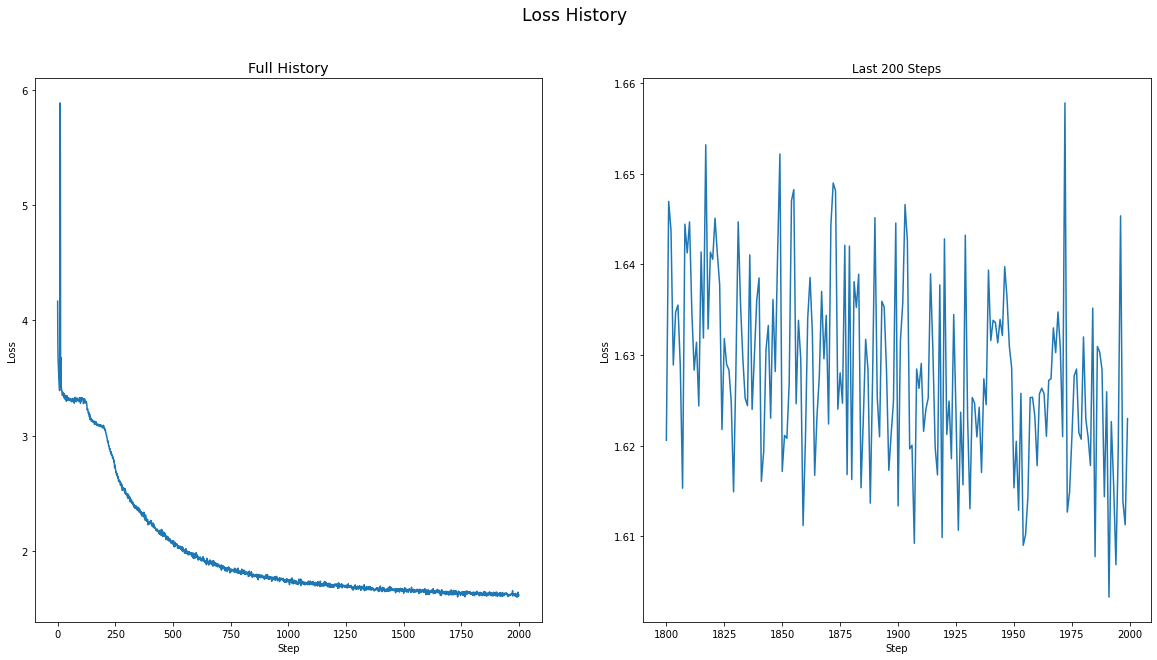

In [ ]:
nsteps = 2000
batch_size=2048 # Drop batch size because larger model

loss_history = train(model, nsteps, batch_size)
make_plots(loss_history, last_n=200)

We can see that this isn't too much better, but again, we see that the model is ***FAR*** from converging.
The previous model was flattening out in the zoomed out view but this one doesn't look even close!

In [ ]:
print(decode(model.generate(idx = torch.zeros((1, 1), dtype=torch.long).to(device), max_new_tokens=500)[0].tolist()))


Which in his grievous to as your gates;
And then on my chance, your goodly bosom,--

KING HENRY VI:
When as you say?
And, this field wench me; he shalt loves you to chance?
Upon Edward, sir, I love the down his loath,
Rosaland blood understood fly: he wouldst no extremity
Told him sort?

HENRY BOLINGBROKE:
Huntsman:
For thy gods ere acquaints letters, to him, or any rightly
And flatter of heaven news, what's to give curtail.

DUCHESS OF YORK:
Henry breath,
Mfount may, good Mowbray's hand?

Provo


This is sounding much closer to English and very much in the style of Shakespeare.
Not quite perfect, but getting close.

Loss: --:   0%|          | 0/2000 [00:00<?, ?it/s]

Final loss: 1.5654897689819336


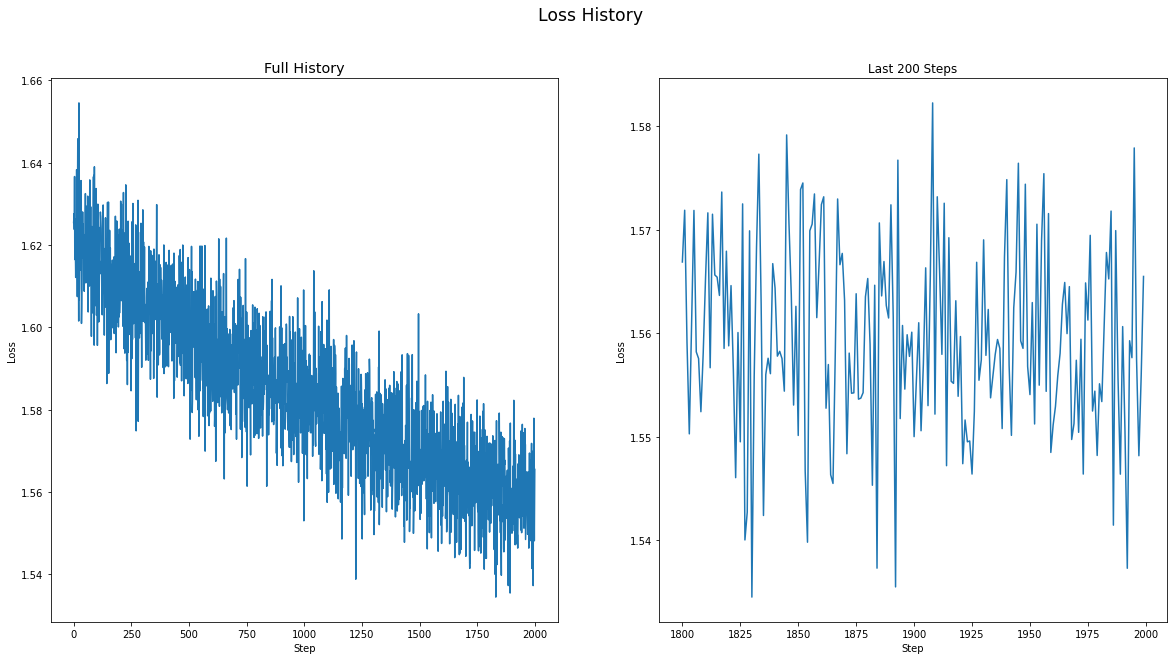

In [ ]:
# Let's train longer.
nsteps = 2000
batch_size=2048
loss_history = train(model, nsteps, batch_size)
make_plots(loss_history, last_n=200)

In [ ]:
print(decode(model.generate(idx = torch.zeros((1, 1), dtype=torch.long).to(device), max_new_tokens=1000)[0].tolist()))


Nurse:
Here cannot weed to part, he losely wind here, but his Lord of Northumberlain dayls too,
But so. I am king: a necessary cruel upon a keysarried youh feel
your loves, thy clouded in England, and the warful measure holy not have had been misering thing to my box,
To flather,
That pon Clifford,
Then know.

HASTINGS:
At a strength,
O'er den tender grave;
Thou art and brothers' becomy:
And if thos the streets, answered with a princross; when we thine estation of us desert'st that, sirs, the unresolution approach was e'er comee, good sir,
So deposed; at hand: therefore, we are now dread with Froth more prayer. What care: I think sith Rome play the breathe subject,
Your wooing it thee enforce.--
Must I; for not, because what often calamity
Bona,
The ass I thought in my lord. I'll hange at favourites is royal blood.

LADY CAPULET:
Ay, I must give me a trickles? Who draw wos not all,
We can bought you, sir, to my confounding your hand?

LUCIO:
Uncle, and
for digniver'd a few,
Stouth whi

You can see that we're doing even better.
Almost Shakespeare!
Even at this point we're not quite converged but we'd probably want to reduce the learning rate if we were to continue.

If we wanted to make even better improvements we could use better tokenizers and embeddings, we did use an extremely naive character level tokenizer.
The real GPT uses a sub-word tokenizer with billions of tokens.

# A Better Tokenizer
Let's just see how things work if we use better tokens and go back to the atto model.
We'll use OpenAI's [tiktoken](https://github.com/openai/tiktoken) (see [cookbook](https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb)) but you can use any from [huggingface](https://huggingface.co/docs/transformers/main_classes/tokenizer) or others.

In [ ]:
!pip install tiktoken

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.8 MB/s eta 0:00:00


In [ ]:
import tiktoken
enc = tiktoken.encoding_for_model("gpt-3.5-turbo")# Like above but we're using text instead of tensor form
split = int(0.9*len(text)) # first 90% will be train, rest val
train_data = text[:split]
valid_data = text[split:]
train_ids = enc.encode_ordinary(train_data)
val_ids = enc.encode_ordinary(valid_data)